<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [4]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-08-30 19:14:10--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  3.83MB/s    in 60s     

2026-08-30 19:15:10 (2.56 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [5]:
# Let's prepare our dataframe with the columns
database_df = df[
    ["DatabaseWantToWorkWith"]
].dropna().copy()

database_df["Database"] = (
    database_df["DatabaseWantToWorkWith"]
    .str.split(";")
)

database_df = database_df.explode("Database")

database_df["Database"] = (
    database_df["Database"]
    .str.strip()
)

In [6]:
# Now let's check the top 5 most desired databases
top_databases = (
    database_df["Database"]
    .value_counts()
    .head(5)
)

top_databases

Database
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

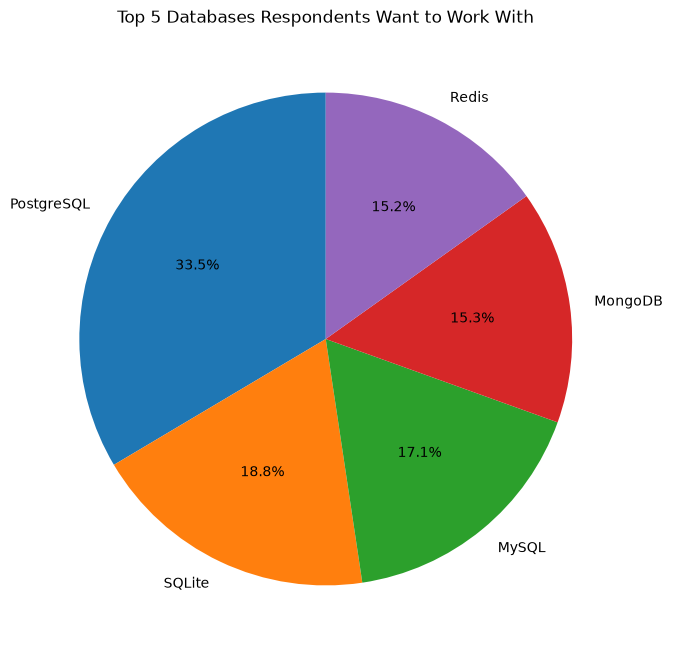

In [7]:
# Now let's visualize the pir chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    top_databases.values,
    labels=top_databases.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Databases Respondents Want to Work With"
)

plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



In [8]:
# Let's prepare the DevType datafrane
devtype_df = df[
    ["DevType"]
].dropna().copy()

devtype_df["DeveloperRole"] = (
    devtype_df["DevType"]
    .str.split(";")
)

devtype_df = devtype_df.explode("DeveloperRole")

devtype_df["DeveloperRole"] = (
    devtype_df["DeveloperRole"]
    .str.strip()
)

In [9]:
# Find the top 5 developer roles
top_roles = (
    devtype_df["DeveloperRole"]
    .value_counts()
    .head(5)
)

top_roles

DeveloperRole
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Name: count, dtype: int64

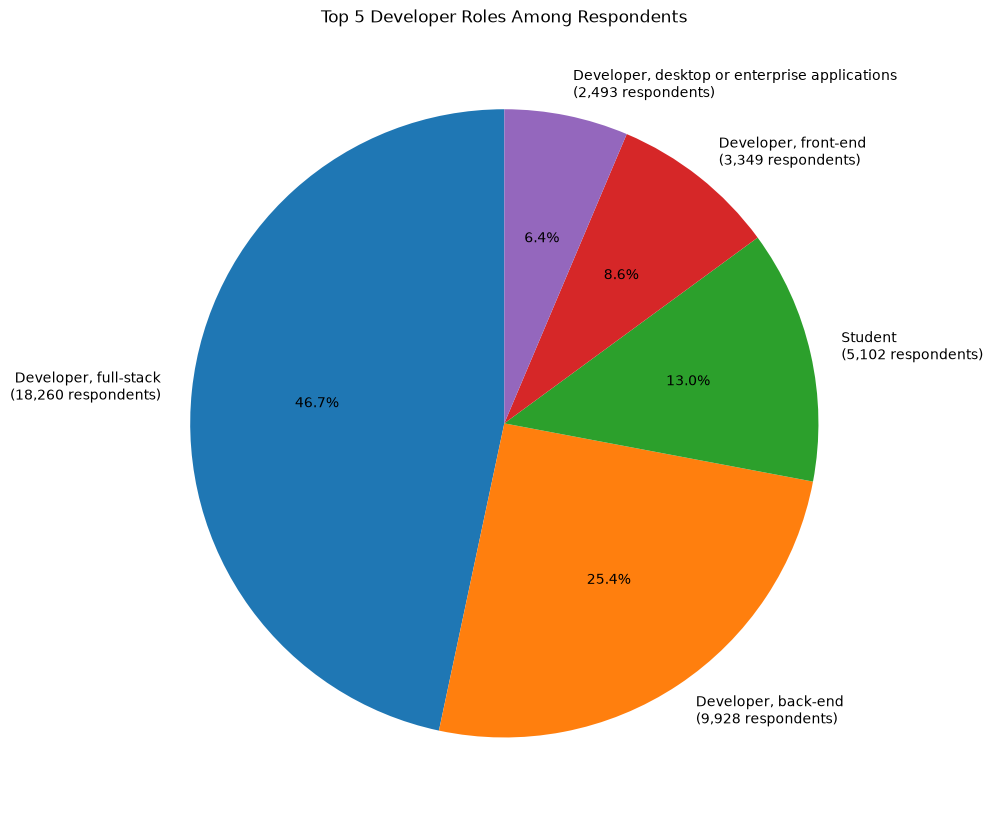

In [10]:
# Now let's visualize the PieChart with the respondents count per role
import matplotlib.pyplot as plt

labels = [
    f"{role}\n({count:,} respondents)"
    for role, count in top_roles.items()
]

plt.figure(figsize=(10, 10))

plt.pie(
    top_roles.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Developer Roles Among Respondents"
)

plt.tight_layout()

plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



In [11]:
# Let's prepare the language dataframe
language_df = df[
    ["LanguageHaveWorkedWith"]
].dropna().copy()

language_df["Language"] = (
    language_df["LanguageHaveWorkedWith"]
    .str.split(";")
)

language_df = language_df.explode("Language")

language_df["Language"] = (
    language_df["Language"]
    .str.strip()
)

In [12]:
# Find the top 5 langauges
top_languages = (
    language_df["Language"]
    .value_counts()
    .head(5)
)

top_languages

Language
JavaScript    37492
HTML/CSS      31816
Python        30719
SQL           30682
TypeScript    23150
Name: count, dtype: int64

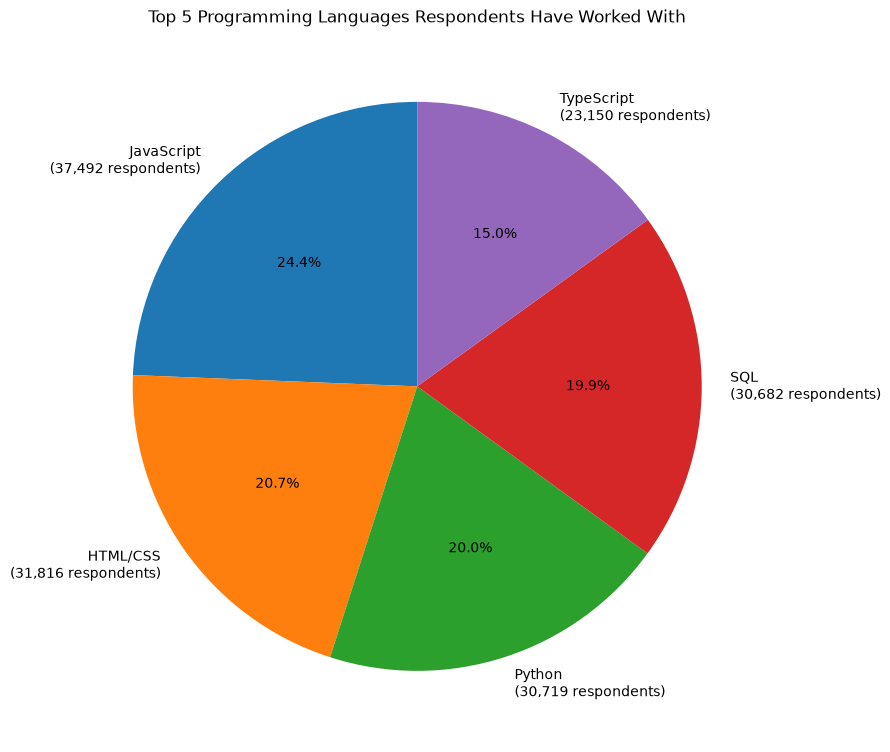

In [13]:
# Visualing the PIeChart including respondents count
import matplotlib.pyplot as plt

labels = [
    f"{language}\n({count:,} respondents)"
    for language, count in top_languages.items()
]


plt.figure(figsize=(9, 9))

plt.pie(
    top_languages.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Programming Languages Respondents Have Worked With"
)

plt.tight_layout()

plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [14]:
# Let's prepare our Dataframe
collab_df = df[
    ["NEWCollabToolsHaveWorkedWith"]
].dropna().copy()

collab_df["CollabTool"] = (
    collab_df["NEWCollabToolsHaveWorkedWith"]
    .str.split(";")
)

collab_df = collab_df.explode("CollabTool")

collab_df["CollabTool"] = (
    collab_df["CollabTool"]
    .str.strip()
)

In [15]:
# Find the top 5 collaboration tools
top_tools = (
    collab_df["CollabTool"]
    .value_counts()
    .head(5)
)

top_tools

CollabTool
Visual Studio Code    42751
Visual Studio         17021
IntelliJ IDEA         15555
Notepad++             13874
Vim                   12523
Name: count, dtype: int64

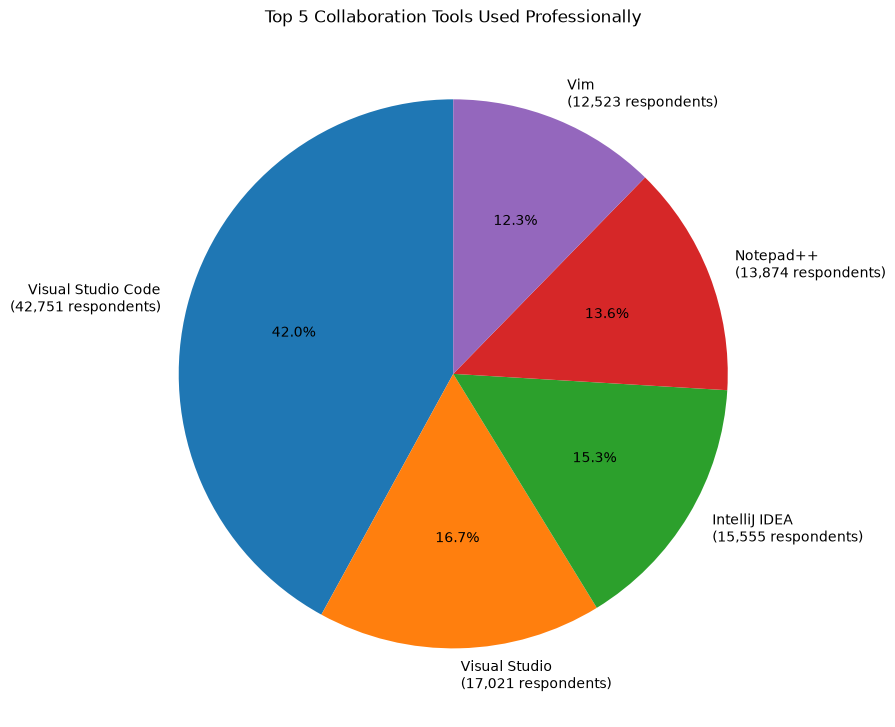

In [16]:
# Visualizing PieChart including Respondents count
import matplotlib.pyplot as plt

labels = [
    f"{tool}\n({count:,} respondents)"
    for tool, count in top_tools.items()
]

plt.figure(figsize=(9, 9))

plt.pie(
    top_tools.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Collaboration Tools Used Professionally"
)

plt.tight_layout()

plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



In [17]:
# Preparing the dataframe
admired_df = df[
    ["LanguageAdmired"]
].dropna().copy()

admired_df["Language"] = (
    admired_df["LanguageAdmired"]
    .str.split(";")
)

admired_df = admired_df.explode("Language")

admired_df["Language"] = (
    admired_df["Language"]
    .str.strip()
)

In [18]:
# Find top 5 admired languages
top_admired = (
    admired_df["Language"]
    .value_counts()
    .head(5)
)

top_admired

Language
JavaScript    21869
Python        20774
SQL           20692
HTML/CSS      19851
TypeScript    16079
Name: count, dtype: int64

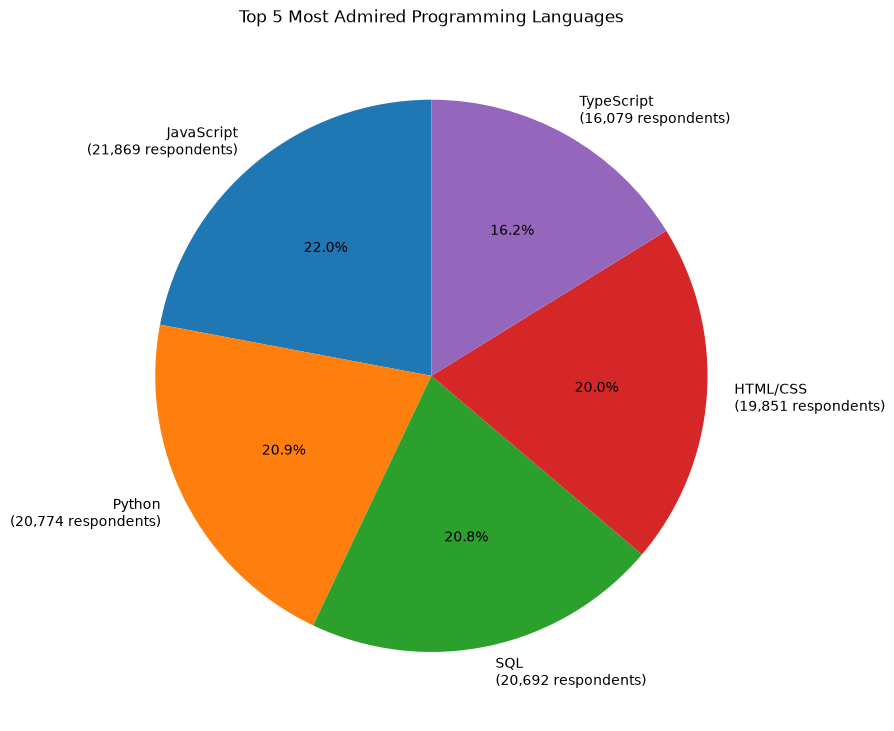

In [19]:
# Visualizing PieChart with respondents count
import matplotlib.pyplot as plt

labels = [
    f"{language}\n({count:,} respondents)"
    for language, count in top_admired.items()
]

plt.figure(figsize=(9, 9))

plt.pie(
    top_admired.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Most Admired Programming Languages"
)

plt.tight_layout()

plt.show()

##### 3.2 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



In [24]:
# Let's prepare the dataFrame
web_df = df[
    ["WebframeWantToWorkWith"]
].dropna().copy()

web_df["WebFramework"] = (
    web_df["WebframeWantToWorkWith"]
    .str.split(";")
)

web_df = web_df.explode("WebFramework")

web_df["WebFramework"] = (
    web_df["WebFramework"]
    .str.strip()
)

In [25]:
# Find the top 5 frameworks
top_frameworks = (
    web_df["WebFramework"]
    .value_counts()
    .head(5)
)

top_frameworks

WebFramework
React           15404
Node.js         14735
Next.js          8507
Vue.js           7604
ASP.NET CORE     6905
Name: count, dtype: int64

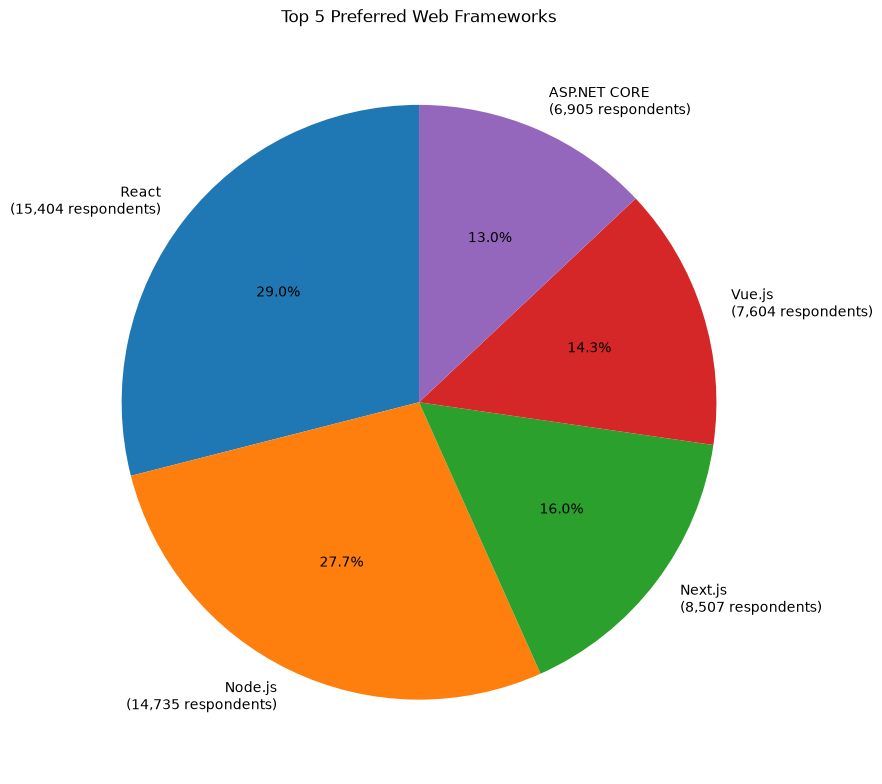

In [26]:
# Visualize PieChart with respondents count
import matplotlib.pyplot as plt

labels = [
    f"{framework}\n({count:,} respondents)"
    for framework, count in top_frameworks.items()
]

plt.figure(figsize=(9, 9))

plt.pie(
    top_frameworks.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Preferred Web Frameworks"
)

plt.tight_layout()

plt.show()

##### 3.3 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [28]:
# Let's prepare the dataframe
embedded_df = df[
    ["EmbeddedWantToWorkWith"]
].dropna().copy()

embedded_df["EmbeddedTechnology"] = (
    embedded_df["EmbeddedWantToWorkWith"]
    .str.split(";")
)

embedded_df = embedded_df.explode(
    "EmbeddedTechnology"
)

embedded_df["EmbeddedTechnology"] = (
    embedded_df["EmbeddedTechnology"]
    .str.strip()
)

In [29]:
# Find the top 5 technologies
top_embedded = (
    embedded_df["EmbeddedTechnology"]
    .value_counts()
    .head(5)
)

top_embedded

EmbeddedTechnology
Rasberry Pi    9792
Arduino        6482
GNU GCC        5870
CMake          4693
Cargo          4567
Name: count, dtype: int64

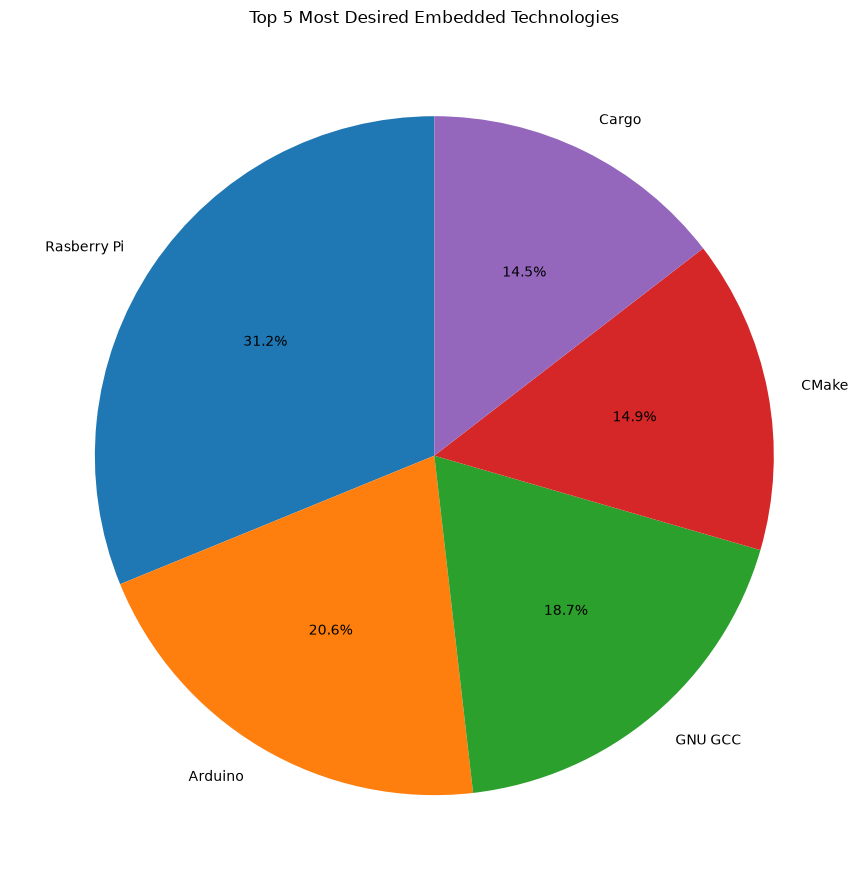

In [30]:
# Visualizing PieChart with Correspondent Count
import matplotlib.pyplot as plt

labels = [
    f"{technology}\n({count:,} respondents)"
    for technology, count in top_embedded.items()
]

plt.figure(figsize=(9, 9))

plt.pie(
    top_embedded.values,
    labels=top_embedded.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Most Desired Embedded Technologies"
)

plt.tight_layout()

plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
